# EDA du corpus — les figures des diapos data
Tout sort des artefacts de l'ETL (`etl/corpus.yml`, rapports, `chunks.jsonl`). Figures écrites dans `figures/`.

In [1]:
import json
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt

ETL = Path("../etl")
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11,
                            "axes.spines.top": False, "axes.spines.right": False})
VERT, BOIS, TERRE = "#3A5A40", "#7A6A4F", "#8C4A3C"

fiches = [json.loads(l) for l in open(ETL / "chunks" / "chunks.jsonl")]
rapport_t = json.load(open(ETL / "chunks" / "rapport-transformation.json"))
rapport_e = json.load(open(ETL / "brut" / "rapport-extraction.json"))
pages_archivees = len([p for p in (ETL / "brut").glob("*/*.json")
                       if p.name not in ("rapport-extraction.json", "redirections.json")])
print(len(fiches), "fiches ·", pages_archivees, "pages en archive")

477 fiches · 156 pages en archive


## Figure 1 — l'entonnoir du corpus : disponible → signé → indexé

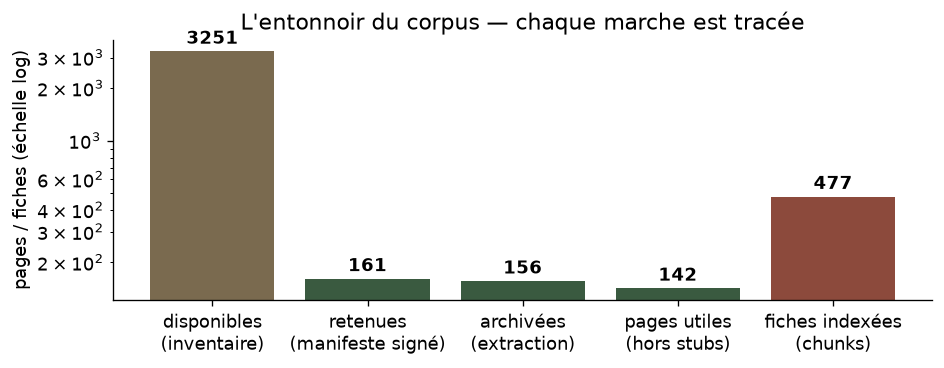

In [2]:
etapes = ["disponibles\n(inventaire)", "retenues\n(manifeste signé)", "archivées\n(extraction)",
          "pages utiles\n(hors stubs)", "fiches indexées\n(chunks)"]
valeurs = [3251, 161, pages_archivees,
           pages_archivees - rapport_t["pages_stubs_ecartees"], len(fiches)]
fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.bar(etapes, valeurs, color=[BOIS, VERT, VERT, VERT, TERRE])
ax.bar_label(bars, fmt="%d", padding=2, fontweight="bold")
ax.set_yscale("log"); ax.set_ylabel("pages / fiches (échelle log)")
ax.set_title("L'entonnoir du corpus — chaque marche est tracée")
plt.tight_layout(); plt.savefig(FIG / "01-entonnoir-corpus.png"); plt.show()

## Figure 2 — couverture : fiches par ouverture, FR et EN

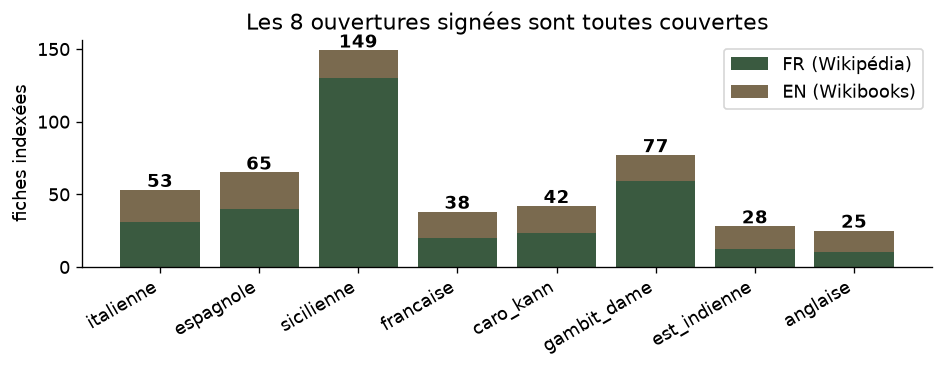

In [3]:
ouvertures = list(rapport_t["par_ouverture"])
fr = [sum(1 for f in fiches if f["ouverture"] == o and f["lang"] == "fr") for o in ouvertures]
en = [sum(1 for f in fiches if f["ouverture"] == o and f["lang"] == "en") for o in ouvertures]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(ouvertures, fr, label="FR (Wikipédia)", color=VERT)
ax.bar(ouvertures, en, bottom=fr, label="EN (Wikibooks)", color=BOIS)
for i, (a, b) in enumerate(zip(fr, en)):
    ax.text(i, a + b + 2, str(a + b), ha="center", fontweight="bold")
ax.set_title("Les 8 ouvertures signées sont toutes couvertes")
ax.set_ylabel("fiches indexées"); ax.legend(); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.savefig(FIG / "02-couverture-ouvertures.png"); plt.show()

## Figure 3 — distribution des longueurs de fiches

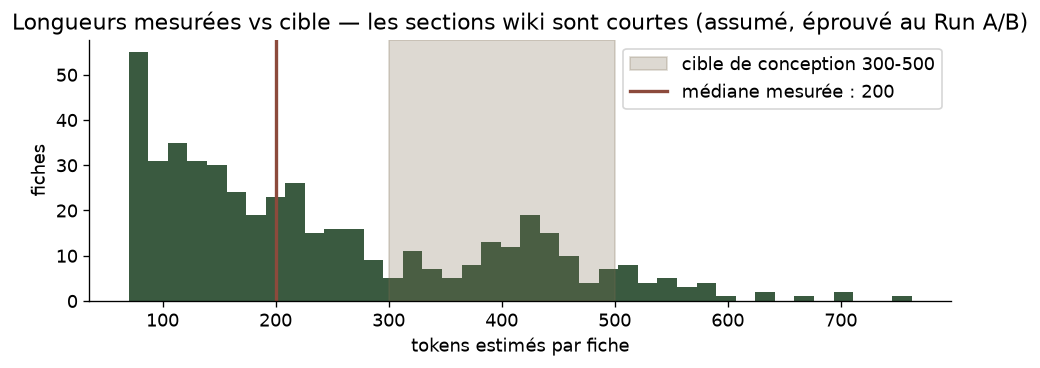

In [4]:
longueurs = [f["n_tokens_est"] for f in fiches]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(longueurs, bins=40, color=VERT)
ax.axvspan(300, 500, color=BOIS, alpha=0.25, label="cible de conception 300-500")
ax.axvline(rapport_t["tokens_mediane"], color=TERRE, lw=2,
           label=f"médiane mesurée : {rapport_t['tokens_mediane']}")
ax.set_title("Longueurs mesurées vs cible — les sections wiki sont courtes (assumé, éprouvé au Run A/B)")
ax.set_xlabel("tokens estimés par fiche"); ax.set_ylabel("fiches"); ax.legend()
plt.tight_layout(); plt.savefig(FIG / "03-longueurs-fiches.png"); plt.show()

## Figure 4 — la qualité du traitement en chiffres

In [5]:
print(f"pages en archive         : {pages_archivees} (absentes au dernier run : {len(rapport_e['absentes'])})")
print(f"stubs écartés            : {rapport_t['pages_stubs_ecartees']}")
print(f"sections découpées       : {rapport_t['sections']}")
print(f"doublons exacts          : {rapport_t['doublons_exacts']}")
print(f"quasi-doublons (Jaccard) : {rapport_t['quasi_doublons']}")
print(f"FEN de référence         : {rapport_t['fen_calcules']} calculés, {rapport_t['fen_echoues']} échec(s)")
print(f"fiches FR / EN           : {rapport_t['par_langue']['fr']} / {rapport_t['par_langue']['en']}")
print(f"licences                 : {set(f['licence'] for f in fiches)}")
print(f"fiches avec source_url   : {sum(1 for f in fiches if f['source_url'])} / {len(fiches)} (attribution CC BY-SA)")

pages en archive         : 156 (absentes au dernier run : 0)
stubs écartés            : 14
sections découpées       : 576
doublons exacts          : 0
quasi-doublons (Jaccard) : 1
FEN de référence         : 95 calculés, 0 échec(s)
fiches FR / EN           : 325 / 152
licences                 : {'CC BY-SA 4.0'}
fiches avec source_url   : 477 / 477 (attribution CC BY-SA)


## Reste à mesurer ailleurs
- Top-20 ouvertures masters vs amateurs (contexte métier) → notebook 04 avec le gold set.
- recall@5 / MRR → runs MLflow A/B (feature Évaluation).